## Классические алгоритмы без ансамблирования
В этом ноутбуке вам нужно обучить модели на датасете классификации из предыдущего ноутбука и сравнить результаты. Вам будет предоставлен baseline, на основе которого вы будете доделывать предсказывающие модели. Оценка лабы будет зависеть от ROC-AUC на тестовых данных по следующим критериям:
\
AUC - на тестовых данных
- $AUC \leq 0.75$ - 0 баллов
- $0.75 < AUC \leq 0.76$ - 2 балла
- $0.76 < AUC \leq 0.77$ - 4 балла
- $0.77 < AUC \leq 0.78$ - 6 баллов
- $0.78 < AUC \leq 0.79$ - 8 баллов
- $AUC > 0.79$ - 10 баллов

\
В этой работе запрещено использовать ансамбли моделей (лес, бустинги и т.д.)!

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import roc_auc_score, precision_score, recall_score, roc_curve, accuracy_score

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [23]:

data = pd.read_csv('german.csv', sep=';')

X = data.iloc[:, 1:].to_numpy()
y = data.iloc[:, 0].to_numpy()    


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

dt_model = DecisionTreeClassifier(max_depth=8, random_state=42)
dt_model.fit(X_train, y_train)
y_pred_proba_dt = dt_model.predict_proba(X_test)[:, 1]
dt_roc_auc = roc_auc_score(y_test, y_pred_proba_dt)
print(f"ROC-AUC дерева: {dt_roc_auc:.4f}")

ROC-AUC дерева: 0.6630


In [24]:
data = pd.read_csv('german.csv', sep=';')
print(data.columns)
X = data.iloc[:, 1:]  
y = data.iloc[:, 0]   
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Index(['Creditability', 'Account_Balance', 'Duration_of_Credit_monthly',
       'Payment_Status_of_Previous_Credit', 'Purpose', 'Credit_Amount',
       'Value_Savings_Stocks', 'Length_of_current_employment',
       'Instalment_per_cent', 'Sex_Marital_Status', 'Guarantors',
       'Duration_in_Current_address', 'Most_valuable_available_asset',
       'Age_years', 'Concurrent_Credits', 'Type_of_apartment',
       'No_of_Credits_at_this_Bank', 'Occupation', 'No_of_dependents',
       'Telephone', 'Foreign_Worker'],
      dtype='object')


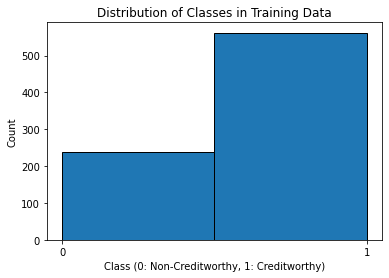

In [25]:
plt.hist(y_train, bins=2, edgecolor='k')
plt.xticks([0, 1])
plt.xlabel('Class (0: Non-Creditworthy, 1: Creditworthy)')
plt.ylabel('Count')
plt.title('Distribution of Classes in Training Data')
plt.show()

--- Дерево решений (Decision Tree) ---
Точность (Accuracy): 0.7150
ROC-AUC: 0.6630


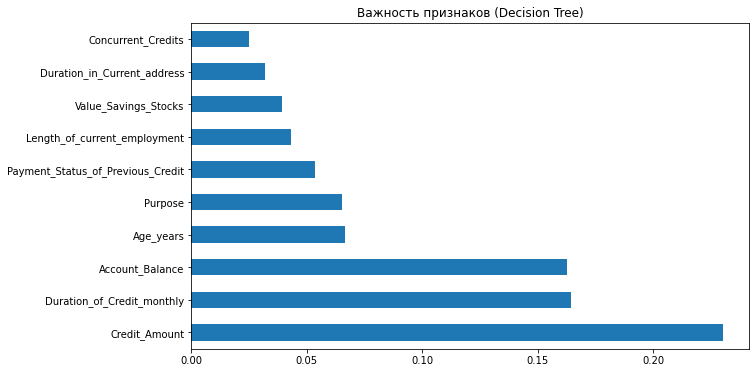

In [26]:
# Ячейка 2.1 Дерево решений (Decision Tree)
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
import pandas as pd
import matplotlib.pyplot as plt

print("--- Дерево решений (Decision Tree) ---")
# Инициализируем и обучаем модель
dt_model = DecisionTreeClassifier(max_depth=8, random_state=42)
dt_model.fit(X_train, y_train)

# Предсказания и оценка
y_pred_dt = dt_model.predict(X_test)
y_pred_proba_dt = dt_model.predict_proba(X_test)[:, 1]  # вероятности для ROC-AUC

dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_roc_auc = roc_auc_score(y_test, y_pred_proba_dt)

print(f"Точность (Accuracy): {dt_accuracy:.4f}")
print(f"ROC-AUC: {dt_roc_auc:.4f}")

# Визуализация важности признаков
plt.figure(figsize=(10, 6))
feature_importance = pd.Series(dt_model.feature_importances_, index=data.columns[1:])  # предполагается, что data - это DataFrame
feature_importance.nlargest(10).plot(kind='barh')
plt.title('Важность признаков (Decision Tree)')
plt.show()

In [30]:
print("--- K ближайших соседей (KNN) ---")
knn_model = KNeighborsClassifier(n_neighbors=7)
knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)
y_pred_proba_knn = knn_model.predict_proba(X_test)[:, 1]

knn_accuracy = accuracy_score(y_test, y_pred_knn)
knn_roc_auc = roc_auc_score(y_test, y_pred_proba_knn)

print(f"Точность (Accuracy): {knn_accuracy:.4f}")
print(f"ROC-AUC: {knn_roc_auc:.4f}")

--- K ближайших соседей (KNN) ---
Точность (Accuracy): 0.6850
ROC-AUC: 0.6156


Обучающая выборка - MSE: 4.17, R2: 0.9887
Тестовая выборка   - MSE: 4.08, R2: 0.9890


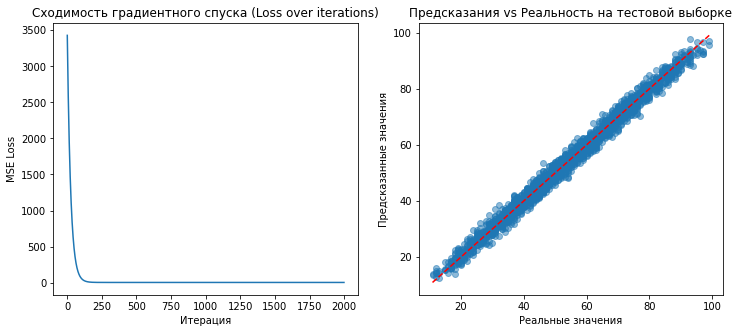

In [36]:
class LinearRegressionGD:
    def __init__(self, learning_rate=0.01, n_iterations=1000, random_state=42):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.random_state = random_state
        self.weights = None
        self.bias = None
        self.loss_history = []

    def _initialize_parameters(self, n_features):
        rng = np.random.RandomState(self.random_state)
        self.weights = rng.randn(n_features) * 0.01
        self.bias = 0.0

    def _compute_loss(self, y_true, y_pred):
        n_samples = len(y_true)
        loss = (1 / n_samples) * np.sum((y_true - y_pred) ** 2)
        return loss

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self._initialize_parameters(n_features)

        for i in range(self.n_iterations):
            y_pred = np.dot(X, self.weights) + self.bias


            loss = self._compute_loss(y, y_pred)
            self.loss_history.append(loss)
            dw = (2 / n_samples) * np.dot(X.T, (y_pred - y))
            db = (2 / n_samples) * np.sum(y_pred - y)

            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

        return self

    def predict(self, X):
        if self.weights is None or self.bias is None:
            raise Exception("Модель еще не обучена. Сначала вызовите метод fit().")
        return np.dot(X, self.weights) + self.bias



df_student = pd.read_csv('Student_Performance.csv')
df_student['Extracurricular Activities'] = df_student['Extracurricular Activities'].map({'Yes': 1, 'No': 0})
X_student = df_student.drop('Performance Index', axis=1).values
y_student = df_student['Performance Index'].values
X_train_st, X_test_st, y_train_st, y_test_st = train_test_split(
    X_student, y_student, test_size=0.2, random_state=42
)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_st)
X_test_scaled = scaler.transform(X_test_st)
model = LinearRegressionGD(learning_rate=0.01, n_iterations=2000)
model.fit(X_train_scaled, y_train_st)

y_pred_train = model.predict(X_train_scaled)
y_pred_test = model.predict(X_test_scaled)

from sklearn.metrics import mean_squared_error, r2_score

mse_train = mean_squared_error(y_train_st, y_pred_train)
mse_test = mean_squared_error(y_test_st, y_pred_test)
r2_train = r2_score(y_train_st, y_pred_train)
r2_test = r2_score(y_test_st, y_pred_test)

print(f"Обучающая выборка - MSE: {mse_train:.2f}, R2: {r2_train:.4f}")
print(f"Тестовая выборка   - MSE: {mse_test:.2f}, R2: {r2_test:.4f}")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(model.loss_history)
plt.title('Сходимость градиентного спуска (Loss over iterations)')
plt.xlabel('Итерация')
plt.ylabel('MSE Loss')

# График предсказанных vs реальных значений
plt.subplot(1, 2, 2)
plt.scatter(y_test_st, y_pred_test, alpha=0.5)
plt.plot([y_test_st.min(), y_test_st.max()], [y_test_st.min(), y_test_st.max()], 'r--')
plt.xlabel('Реальные значения')
plt.ylabel('Предсказанные значения')
plt.title('Предсказания vs Реальность на тестовой выборке')
plt.show()

## Экспериментируйте
Для получения лучшего качества придется поэкспериментировать. Подсказка: попробуйте оптимизировать гиперпараметры модели